In [1]:
import pandas as pd

URL = "https://drive.google.com/uc?export=download&id="

sales = pd.read_csv(URL + "1LlA5ni-10NzZq6ODU4eq8AlB6zi0WlDA")

sales = sales.drop_duplicates()

sales["BranchID"] = (
    sales["BranchID"]
    .str.strip()
    .str.upper()
    .str.replace("-", "", regex=False)
)

sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

sales = sales.dropna(subset=["Date"])

sales["YM"] = sales["Date"].dt.to_period("M").astype(str)

df = sales.groupby(
    ["BranchID", "YM"],
    as_index=False
)["Amount"].sum()

df

,BranchID,YM,Amount
0,B01,2025-01,32340.00
1,B01,2025-02,27090.00
2,B01,2025-03,32480.00
3,B01,2025-04,31215.00
4,B01,2025-05,33165.00
...,...,...,...
103,B06,2026-02,11080.53
104,B06,2026-03,12450.00
105,B06,2026-04,11490.00
106,B06,2026-05,14960.00


In [3]:
df["Amount"].describe()

,Amount
count,108.000000
mean,23246.720370
std,7623.076998
min,8310.000000
25%,18455.000000
50%,23005.000000
75%,28135.000000
max,44885.000000


In [4]:
df["Amount"].skew()

np.float64(0.19533492889659224)

<Axes: >

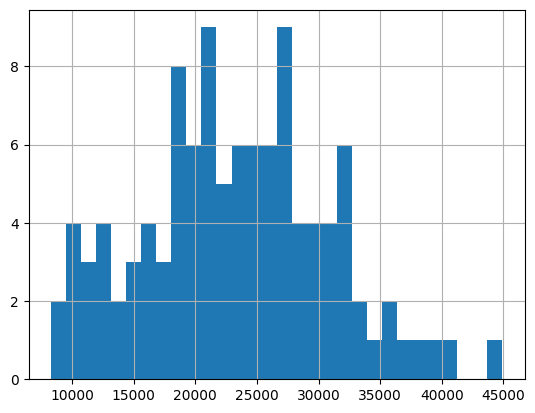

In [5]:
df["Amount"].hist(bins=30)

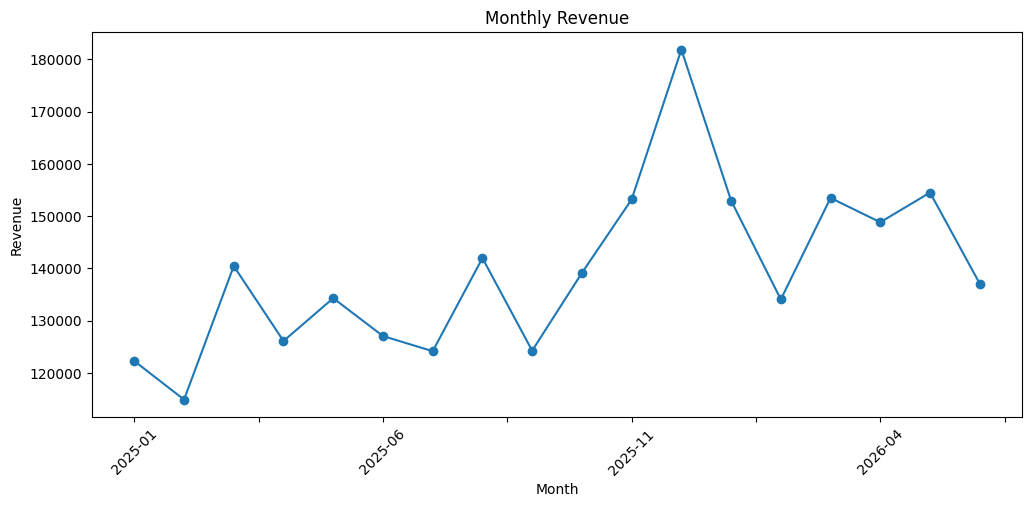

In [6]:
import matplotlib.pyplot as plt

monthly = df.groupby("YM")["Amount"].sum()

monthly.plot(kind="line", figsize=(12,5), marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [7]:
monthly.mean()

np.float64(139480.32222222222)

In [8]:
monthly.idxmax(), monthly.max()

('2025-12', 181900.0)

In [9]:
((monthly.max() - monthly.mean()) / monthly.mean()) * 100

np.float64(30.412661156743013)

In [11]:
q1, q3 = df["Amount"].quantile([.25, .75])

fence_hi = q3 + 1.5 * (q3 - q1)

df[df["Amount"] > fence_hi]

,BranchID,YM,Amount
11,B01,2025-12,44885.0


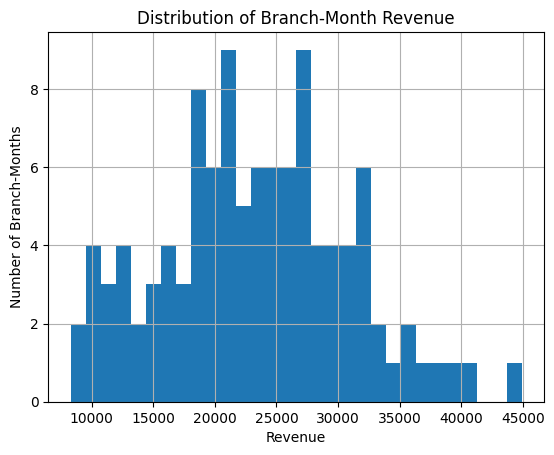

In [12]:
df["Amount"].hist(bins=30)

plt.title("Distribution of Branch-Month Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Branch-Months")
plt.show()

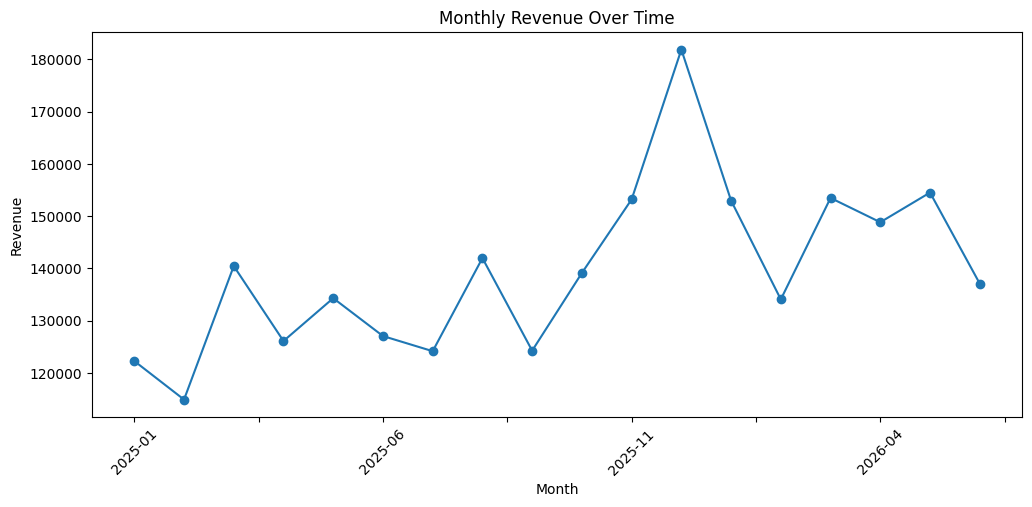

In [13]:
monthly = df.groupby("YM")["Amount"].sum()

monthly.plot(kind="line", marker="o", figsize=(12,5))

plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

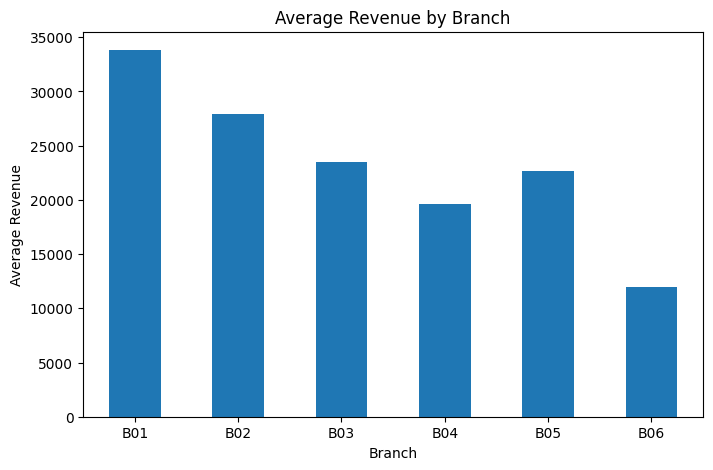

In [14]:
branch_revenue = df.groupby("BranchID")["Amount"].mean()

branch_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Revenue")
plt.xticks(rotation=0)
plt.show()

In [20]:
# Connect Sales with Products
sales_products = sales.merge(
    products[["ProductID", "ProductName"]],
    on="ProductID",
    how="left"
)

# Total revenue per product
product_revenue = sales_products.groupby("ProductName")["Amount"].sum()

# Get the top 2 products
top_2 = product_revenue.nlargest(2)

# Calculate revenue share
share = (top_2.sum() / product_revenue.sum()) * 100

print("Top 2 products:")
print(top_2)

print("Revenue share of the top 2 products:", round(share, 2), "%")

NameError: name 'products' is not defined

The dataset has **10,589** sales rows.
There are **23** duplicate SaleIDs that need to be removed.
The highest branch-month revenue is **44,885**.
The top 2 products account for **28.98%** of total revenue.
The strongest month is about **30.41%** higher than the monthly average.